# Evaluation Metrics

This notebook connects two evaluation problems seen in practice: predicting something numeric, like weekly electricity demand or delivery time (i.e. **Regression**) and deciding between two outcomes, like fraud vs legitimate transactions (i.e. **Binary classification**).

### Notebook roadmap

| Part | What you'll do | Key question |
|------|---------------|-------------|
| **1. Regression metrics** | Build MAE and MSE from scratch, then compare two models | *How wrong is "wrong"? Does one big miss matter more than many small ones?* |
| **2. Binary classification** | Measure a spam filter with accuracy, then discover why accuracy is misleading | *Can a model score 82 % and still be useless?* |
| **3. Precision, Recall, F₁** | Use the confusion matrix and learn metrics that care about different kinds of mistakes | *Is it worse to miss real spam or to flag a real email?* |
| **4. F-beta & trade-offs** | Tune the balance between precision and recall | *How do you tell a metric which mistakes matter most?* |

#### What to notice before you start

For **regression**, imagine a hospital emergency department predicting how many patients will arrive each hour so they can staff accordingly. A model that is accurate on average still puts lives at risk if it badly underestimates a sudden surge and the ER is overwhelmed.

For **binary classification**, imagine a medical screening test for a serious disease. Clearing someone who is actually sick (false negative) could delay life saving treatment, while flagging a healthy person (false positive) triggers unnecessary stress and follow-up. Different mistakes carry very different costs, so accuracy alone is rarely enough.

As you work, keep asking: **What real-world mistake would this metric reward or punish?**

<p align="center"><img src="https://i.sstatic.net/Kq0OH.jpg" width="350"/></p>

[Source: economics.stackexchange.com - Type I/II error pregnancy test analogy](https://economics.stackexchange.com/questions/27677/type-i-error-type-ii-error-pregnancy-test-analogy-is-it-legit)


**Suggested reading**

<details>
<summary>Müller and Guido, <em>Introduction to Machine Learning with Python</em>, Section 5.3.2: Metrics for Binary Classification</summary>

Accuracy can look strong even when a model completely misses the class you actually care about. The useful continuation is the confusion matrix, then precision, recall, F1, threshold changes, precision-recall curves, ROC curves, and AUC, because each tells you something different about false positives and false negatives.

Continue in the book with **Section 5.3.2, Metrics for Binary Classification**, especially the parts on confusion matrices, precision/recall, changing the decision threshold, precision-recall curves, ROC curves, and AUC.
</details>

<details>
<summary>Müller and Guido, <em>Introduction to Machine Learning with Python</em>, Sections 5.3.4 and 5.3.5: Regression Metrics and Using Evaluation Metrics in Model Selection</summary>

For regression, metric choice should follow the real objective: MAE highlights average miss size, MSE punishes large misses more sharply, and R² gives a broad summary of fit. The natural next step is seeing how those choices affect model selection rather than treating metrics as isolated formulas.

Continue in the book with **Section 5.3.4, Regression Metrics**, and then **Section 5.3.5, Using Evaluation Metrics in Model Selection**.
</details>

In [1]:
# Import needed libraries
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score 

## 1) Regression: *How wrong is "wrong"?*

Regression is used to predict a (real) number. In the example in the cell below we have 12 data points in the variable *data*. The variables *prediction1* and *prediction2* are the predictions generated by two regression models.

In [2]:
data = [0.6, 1.4, 2, 2.1, 2.5, 4, 5, 5.5, 6, 7.8, 8, 14]
prediction1 = [-0.41, 0.55, 1.52, 2.49, 3.46, 4.42, 5.39, 6.36, 7.33, 8.3, 9.27, 10.23]
prediction2 = [-1.41, -0.25, 0.92, 2.09, 3.26, 4.42, 5.59, 6.76, 7.93, 9.1, 10.27, 11.43]

In the plot you can see both predictions and the original data.

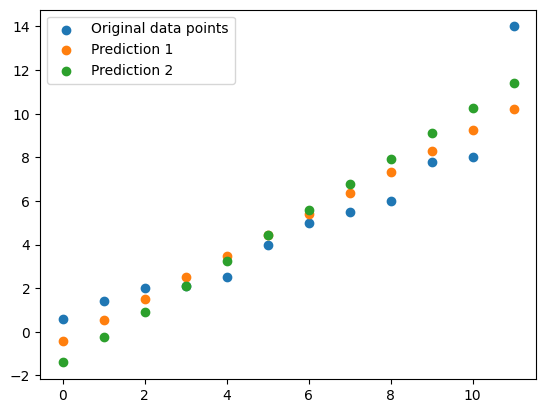

In [3]:
plt.scatter(range(len(data)), data, label='Original data points')
plt.scatter(range(len(data)), prediction1, label='Prediction 1')
plt.scatter(range(len(data)), prediction2 , label='Prediction 2')
plt.legend(loc='upper left')

Based on just the plot it might be difficult to decide whether the *prediction1* or the *prediction2* is better. Luckily we can calculate objective measures to determine which is better. 

### Exercise 1: Mean Absolute Error (MAE) and Mean Squared Error (MSE). *Does one big miss outweigh many small ones?*

#### Part 1: Getting Warmed Up

Write code to compute and print the `MAE` between two lists of values, *volume* and *predicted_volume*. You can assume the lengths of the lists are equal and have more than 1 element each. 

> *Hint* start by using a for-loop to compute the absolute value between the $i^{th}$ value of each list.


In [4]:
volume = [8.3, 9.27, 10.23, -0.41, 0.55, 1.52, 2.49, 3.46, 4.42, 5.39, 6.36, 7.33]
predicted_volume = [0.6, 1.4, 2, 2.1, 2.5, 4, 5, 5.5, 6, 7.8, 8, 14]

"""
Intuition for MAE
MAE asks "on average, what is the absolute difference between the true and predicted values?"
The loop iterates over paired observations, computes the absolute difference with abs(...),
and accumulates those values. After the loop, dividing by the number of points
converts the total error into an average error per prediction.
"""

sum_abs = 0
for i in range(len(volume)):
    sum_abs += abs(volume[i] - predicted_volume[i])  # add one absolute difference for each paired observation
mae_xy = sum_abs / len(volume)  # average absolute difference across all points

print(f'\tMAE: {mae_xy:04.3f}')

	MAE: 3.966


<details>
<summary>🐍 Python recap with <code>range()</code>, <code>len()</code>, <code>abs()</code>, <code>+=</code>, and f-strings</summary>

- **`len(lst)`** returns the number of elements in a list.
- **`range(n)`** generates integers `0, 1, …, n-1`. This is useful for indexing with `lst[i]`.
- **`abs(x)`** returns the absolute value (strips the sign).
- **`+=`** is shorthand. `a += b` means `a = a + b`.
- **f-strings** embed an expression in a string, as in `f'{value:04.3f}'`. Here `04.3f` means at least 4 characters wide with 3 decimal places.
</details>

#### Part 2: Generalize Your MAE Solution to a Function

Based on your code above, generalize your solution to write a function to compute the Mean Absolute Error (MAE) for any two lists of values. As before, you can assume the lengths of the lists are equal and have more than 1 element each.

In [5]:
def mean_absolute_e(y_true, y_pred):
    """Return the mean absolute error (MAE).
    """
    sum_abs = 0
    for i in range(len(y_true)):
        sum_abs += abs(y_true[i] - y_pred[i])
    return sum_abs / len(y_true)

In [6]:
print('Prediction 1:')
print(f'\tMAE: {mean_absolute_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMAE: {mean_absolute_e(data, prediction2):04.3f}')

Prediction 1:
	MAE: 1.019
Prediction 2:
	MAE: 1.321


#### Part 3: Adapt Your MAE Solution to Write an MSE Function

Based on your solution to Part 2 above, adapt your MAE function to write a function to compute the Mean Squared Error (MSE) for any two lists of values. As before, you can assume the lengths of the lists are equal and have more than 1 element each. If you are stuck, repeat Part 1 (without a function) for MSE before building your function.

In [7]:
def mean_squared_e(y_true, y_pred):
    """Return the mean squared error (MSE).
    
    Intuition
    This follows the same structure as MAE, but each error is squared
    before being added. Squaring causes large errors to contribute more heavily
    than small errors, so the final average is more sensitive to outliers.
    """
    sum_sq = 0
    for i in range(len(y_true)):
        sum_sq += (y_true[i] - y_pred[i]) ** 2  # square instead of abs
    return sum_sq / len(y_true)

<details>
<summary>🐍 Python recap: the <code>**</code> operator</summary>

- **`x ** 2`** squares `x`. More generally, `x ** n` raises `x` to the power `n`.
- Equivalent to `pow(x, n)`. (`math.pow(x, n)` also works but always returns a float.)\n
</details>

In [8]:
print('Prediction 1:')
print(f'\tMSE: {mean_squared_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMSE: {mean_squared_e(data, prediction2):04.3f}')

Prediction 1:
	MSE: 1.830
Prediction 2:
	MSE: 2.316


#### Additional coding challenge 1

When you have completed the rest of the exercise, using only python (no numpy or functions from other packages) and without using a loop, write functions to compute the Mean Absolute Error (MAE) and Mean Squared Error (MSE) for any two lists of values.

In [9]:
# Using List comprehension
def mean_absolute_e(y_true, y_pred):
    """Return the mean absolute error (MAE) without an explicit loop.
    
    Expression breakdown
    1. zip(y_true, y_pred) pairs each true value with its prediction.
    2. abs(t - p) computes the absolute error for each pair.
    3. sum(...) accumulates all absolute errors.
    4. Dividing by len(y_true) converts the total absolute error into a mean.
    """
    abs_errors = [abs(t - p) for t, p in zip(y_true, y_pred)]
    total_abs_error = sum(abs_errors)
    return total_abs_error / len(y_true)

<details>
<summary>🐍 Python recap with <code>zip()</code> and list comprehensions</summary>

- **`zip(a, b)`** pairs elements from two lists. For example, `zip([1,2], [3,4])` gives `(1,3), (2,4)`.
- **`for t, p in zip(a, b)`** unpacks each pair into two variables, so no index is needed.
- A **list comprehension** such as `[abs(t - p) for t, p in zip(a, b)]` builds a new list by applying an expression to each pair.
</details>

In [10]:
print('Prediction 1:')
print(f'\tMAE: {mean_absolute_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMAE: {mean_absolute_e(data, prediction2):04.3f}')

Prediction 1:
	MAE: 1.019
Prediction 2:
	MAE: 1.321


In [11]:
def mean_squared_e(y_true, y_pred):
    """Return the mean squared error (MSE) without an explicit loop.
    
    Expression breakdown
    1. zip(y_true, y_pred) pairs corresponding true and predicted values.
    2. (t - p) ** 2 computes the squared error for each pair.
    3. sum(...) accumulates all squared errors.
    4. Dividing by len(y_true) converts the total squared error into a mean.
    """
    squared_errors = [(t - p) ** 2 for t, p in zip(y_true, y_pred)]
    total_squared_error = sum(squared_errors)
    return total_squared_error / len(y_true)

In [12]:
print('Prediction 1:')
print(f'\tMSE: {mean_squared_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMSE: {mean_squared_e(data, prediction2):04.3f}')

Prediction 1:
	MSE: 1.830
Prediction 2:
	MSE: 2.316


#### Additional coding challenge 2

When you have completed the rest of the exercise, use function(s) from the numpy package to make your solution to the additional coding challenge 1 even faster:  write functions to compute the Mean Absolute Error (MAE) and Mean Squared Error (MSE) for any two lists of values.

> *Hint* It's actually easier to implement this with the functions in numpy than only python functions.

In [13]:
# Using Numpy functions
def mean_absolute_e(y_true, y_pred):
    """Return the mean absolute error (MAE) using NumPy.
    
    Intuition
    NumPy performs this calculation with vectorized array operations.
    The lists are converted to arrays, subtracted element by element to obtain
    signed differences, transformed to absolute differences, and then averaged
    with np.mean().
    """
    true_array = np.array(y_true)
    pred_array = np.array(y_pred)
    abs_errors = np.abs(true_array - pred_array)
    return np.mean(abs_errors)

<details>
<summary>🔢 NumPy recap with arrays, element-wise operations, <code>np.mean()</code>, and <code>np.abs()</code></summary>

- **`np.array(lst)`** converts a Python list into a NumPy array, which supports element-wise math.
- **Element-wise operations** let arrays operate value by value. For example, `np.array([1,2]) - np.array([3,1])` gives `array([-2, 1])`, so no loop is needed.
- **`np.abs(arr)`** takes the absolute value of every element. **`np.mean(arr)`** returns the average.
- These chain naturally. `np.mean(np.abs(a - b))` computes MAE in one expression.
</details>

In [15]:
print('Prediction 1:')
print(f'\tMAE: {mean_absolute_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMAE: {mean_absolute_e(data, prediction2):04.3f}')

Prediction 1:
	MAE: 1.019
Prediction 2:
	MAE: 1.321


In [16]:
def mean_squared_e(y_true, y_pred):
    """Return the mean squared error (MSE) using NumPy.
    
    Intuition
    Subtract the arrays element by element to obtain all errors, square
    those errors so large errors contribute more heavily, and then average the
    squared errors. This is the vectorized form of the loop-based calculation.
    """
    true_array = np.array(y_true)
    pred_array = np.array(y_pred)
    squared_errors = (true_array - pred_array) ** 2
    return np.mean(squared_errors)

In [17]:
print('Prediction 1:')
print(f'\tMSE: {mean_squared_e(data, prediction1):04.3f}')
print('Prediction 2:')
print(f'\tMSE: {mean_squared_e(data, prediction2):04.3f}')

Prediction 1:
	MSE: 1.830
Prediction 2:
	MSE: 2.316


#### Part 4: Using Scikit-Learn

The library scikit-learn contains functions to calculate the metrics above. Import them from `sklearn.metrics` and test them, they should produce the same values as your solutions to Parts 2 and 3.

> **Hint:** Find the docs here: [`mean_absolute_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html) and [`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html).

In [18]:
# see above: from sklearn.metrics import mean_absolute_error, mean_squared_error
print('Prediction 1:')
scikit_learn_mae = mean_absolute_error(data, prediction1)
scikit_learn_mse = mean_squared_error(data, prediction1)
print(f'\tMAE: {scikit_learn_mae:04.3f}')
print(f'\tMSE: {scikit_learn_mse:04.3f}')
print('Prediction 2:')
scikit_learn_mae = mean_absolute_error(data, prediction2)
scikit_learn_mse = mean_squared_error(data, prediction2)
print(f'\tMAE: {scikit_learn_mae:04.3f}')
print(f'\tMSE: {scikit_learn_mse:04.3f}')

Prediction 1:
	MAE: 1.019
	MSE: 1.830
Prediction 2:
	MAE: 1.321
	MSE: 2.316


#### ⏱ Speed comparison

The three MSE implementations produce the same answer, but they do very different amounts of work under the hood. With a tiny dataset (say 100 values) sklearn actually looks *slower* because it spends time on input validation, type checking, and array conversion before any math happens. That fixed overhead is invisible once the dataset is large enough for the actual computation to dominate. The cell below generates 100 000 random values so the speed difference becomes clear.

In [19]:
# Generate a larger dataset so the speed difference is visible
np.random.seed(42)
big_true = list(np.random.randn(100_000))
big_pred = list(np.random.randn(100_000))

# For-loop version (from Part 3)
def mse_loop(y_true, y_pred):
    sum_sq = 0
    for i in range(len(y_true)):
        sum_sq += (y_true[i] - y_pred[i]) ** 2
    return sum_sq / len(y_true)

# NumPy version (from Additional coding challenge 2)
def mse_numpy(y_true, y_pred):
    true_array = np.array(y_true)
    pred_array = np.array(y_pred)
    squared_errors = (true_array - pred_array) ** 2
    return np.mean(squared_errors)

print("For-loop MSE:")
%timeit mse_loop(big_true, big_pred)

print("\nNumPy MSE:")
%timeit mse_numpy(big_true, big_pred)

print("\nsklearn MSE:")
%timeit mean_squared_error(big_true, big_pred)

For-loop MSE:


15.9 ms ± 305 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

NumPy MSE:
5.93 ms ± 432 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

sklearn MSE:
4.11 ms ± 323 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<details>
<summary>📦 sklearn recap with <code>mean_absolute_error</code> and <code>mean_squared_error</code></summary>

- **`mean_absolute_error(y_true, y_pred)`** returns MAE, the average of |true − pred| across all samples.
- **`mean_squared_error(y_true, y_pred)`** returns MSE, the average of (true − pred)².
- Both accept lists or NumPy arrays. The first argument is always the ground truth. The second is predictions.
</details>

#### 🔍 Stop and interpret

Look at the MAE and MSE values you computed for Prediction 1 and Prediction 2.

1. **Which model wins under MAE?** Which wins under **MSE**? Do the two metrics agree?
2. **Why might they disagree?** MAE treats every miss equally: off by 1 counts the same whether it happens once or ten times. MSE *squares* each error, so a single large miss is punished much more heavily than several small ones.
3. **Back to the ER scenario:** If you need to avoid catastrophic understaffing during a patient surge, which metric better captures your concern, MAE or MSE?

> **Take-away:** The choice between MAE and MSE is not about which is "better." It is about whether you care more about *average* accuracy or about *worst-case* misses.

## 2) Binary classification: *Right or wrong, but not all mistakes are equal*

In regression we measured **how far off** a prediction was. Now we switch to a world where every prediction is either correct or incorrect. There is no "close."

Binary classification is applicable when there are only two possible answers (e.g., yes/no, good/bad, positive/negative). That sounds simpler, but it hides a trap: **not all mistakes cost the same.** Flagging a real email as spam (annoying) is very different from letting actual spam through (risky).

In the cell below we have the actual labels and predictions for 100 emails. The variable *spam* records whether each email really is spam, and *flagged* records whether a model predicted spam. We use *0* (not-spam) and *1* (spam) as the possible outcomes.

**Suggested reading**

<details>
<summary>Müller and Guido, <em>Introduction to Machine Learning with Python</em>, Section 5.3.2: Metrics for Binary Classification</summary>

Accuracy can look strong even when a model completely misses the class you care about. The book walks through confusion matrices, precision, recall, F1, decision thresholds, precision-recall curves, ROC curves, and AUC, each telling you something different about false positives and false negatives.

Continue in the book with **Section 5.3.2, Metrics for Binary Classification**.
</details>

In [20]:
spam = [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 
           0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
           0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 
           0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0]

flagged = [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
               0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0]

### Exercise 2: Accuracy. *The metric that can fool you*

#### Part 1

We can evaluate our model using accuracy, which tells us how often it was correct. Write code to compute the accuracy between the *spam* and *flagged* variables.

**Note**: In python you can use `==` to test if two values are equal. This will return a boolean value (`True` or `False`). However, in python you can also add two boolean values together and in that case `True` is treated as the value 1 while `False` is treated as the value 0. Therefore:

In [21]:
"""
Python treats True as 1 and False as 0 in arithmetic.
This means you can add comparison results together to count
how many matched, which is the trick the accuracy loop uses.
"""

index_0 = spam[0] == flagged[0]

index_1 = spam[1] == flagged[1]

sum_01 = index_0 + index_1

# two boolean values
print("Boolean value at index 0:", index_0)
print("Boolean value at index 1:", index_1)

# whose sum is an integer
print("Sum is integer:", sum_01)

Boolean value at index 0: False
Boolean value at index 1: True
Sum is integer: 1


In [22]:
"""
Intuition: accuracy counts how many predictions are exactly right.
The loop checks one email at a time, adds 1 for a correct prediction and 0 for
an incorrect one, then divides by the total number of emails to get a fraction.
"""

sum_eq = 0
for i in range(len(spam)):
    sum_eq += (spam[i] == flagged[i])  # True counts as 1, False as 0
accuracy = sum_eq / len(spam)
print(accuracy)

0.91


<details>
<summary>🐍 Python recap: <code>==</code> returns a bool, and bools are numbers</summary>

- **`a == b`** returns `True` or `False`.
- In arithmetic, **`True` behaves as `1`** and **`False` as `0`**, so adding comparisons with `+=` counts how many match.
</details>

#### Part 2

Adapt your code above to write a function that computes the accuracy.


In [23]:
def accuracy(y_true, y_pred):
    """Return the accuracy.
    
    Intuition: compare each true label with its prediction, count the exact
    matches, and divide by the total number of examples. Accuracy is therefore
    the proportion of correct predictions.
    """
    sum_eq = 0
    for i in range(len(y_true)):
        sum_eq += (y_true[i] == y_pred[i])
    acc = sum_eq / len(y_true)
    return acc

In [24]:
print(accuracy(spam, flagged))

0.91


#### Additional coding challenge 3

When you have completed the rest of the exercise, write the function in part 2 above without using any loops.

In [25]:
# Using List comprehension
def accuracy(y_true, y_pred):
    """Return the accuracy without an explicit loop.
    
    Breakdown of the expression:
    1. zip(y_true, y_pred) pairs each true label with its prediction.
    2. t == p evaluates to True for a correct prediction and False otherwise.
    3. sum(...) counts the True values as 1s.
    4. dividing by len(y_true) converts the count into a proportion.
    """
    matches = [t == p for t, p in zip(y_true, y_pred)]
    correct_predictions = sum(matches)
    return correct_predictions / len(y_true)

print(accuracy(spam, flagged))

0.91


#### Additional coding challenge 4

When you have completed the rest of the exercise, use function(s) from the numpy package to make your solution to the additional coding challenge 3 even faster.

In [26]:
# Using Numpy
def accuracy(y_true, y_pred):
    """Return the accuracy using NumPy.
    
    Intuition: NumPy compares the two arrays element by element, producing a
    boolean array. np.mean() interprets True as 1 and False as 0, so the mean
    of that boolean array is the accuracy.
    """
    true_array = np.array(y_true)
    pred_array = np.array(y_pred)
    matches = true_array == pred_array
    return np.mean(matches)

print(accuracy(spam, flagged))

0.91


#### Part 3: Using Scikit-Learn

The library scikit-learn contains functions to calculate accuracy. Import them from `sklearn.metrics` and test them, they should produce the same values as your solutions to Parts 2 and 3.

In [27]:
# see above: from sklearn.metrics import accuracy_score

print('Accuracy using Scikit-learn library')
print(accuracy_score(spam, flagged))

Accuracy using Scikit-learn library
0.91


<details>
<summary>📦 sklearn recap with <code>accuracy_score</code></summary>

- **`accuracy_score(y_true, y_pred)`** returns the fraction of predictions that exactly match the true labels.
- It works for any number of classes, not just binary.
</details>

#### 🚨 The accuracy trap: can high accuracy be meaningless?

Before moving on, let's check how balanced our dataset really is. Run the cell below. It builds the *laziest possible model*: one that **always predicts "not spam"** and never looks at the email at all.

In [28]:
# The "lazy baseline": predict every email as NOT spam (always 0)
lazy_prediction = [0] * len(spam)

lazy_accuracy = accuracy_score(spam, lazy_prediction)
real_accuracy  = accuracy_score(spam, flagged)

print(f"Spam filter accuracy:   {real_accuracy:.0%}")
print(f"Lazy 'always 0' model:  {lazy_accuracy:.0%}")
print(f"\nSpam emails in dataset: {sum(spam)} out of {len(spam)} ({sum(spam)/len(spam):.0%})")
print("\n→ The lazy model never detects a single spam email,")
print("  yet it still scores {:.0f}% accuracy!".format(lazy_accuracy * 100))

Spam filter accuracy:   91%
Lazy 'always 0' model:  83%

Spam emails in dataset: 17 out of 100 (17%)

→ The lazy model never detects a single spam email,
  yet it still scores 83% accuracy!


**What just happened?** Only 17 out of 100 emails are spam, so a model that *ignores the problem entirely* still gets 83 % accuracy. That is the **class imbalance trap**. Accuracy rewards predicting the majority class and can hide a model that has learned nothing useful.

This is exactly why we need metrics that look **inside** the mistakes. That's where precision, recall, and the confusion matrix come in.

> This is one of the most important lessons in applied ML. As the book says: *"Accuracy can look strong even when a model completely misses the class you actually care about."* (Müller & Guido, Section 5.3.2)

### Exercise 3: Precision and Recall. *Which kind of mistake hurts more?*

Think about our spam filter in terms of two very different failure modes:

| Mistake | Technical name | What happens to the user |
|---------|---------------|-------------------------|
| A real email lands in the spam folder | **False Positive (FP)** | You miss an important message |
| A spam email sneaks into the inbox | **False Negative (FN)** | You get annoyed (or worse, phished) |

Are these equally bad? Usually not, and that's why we need **precision** and **recall** instead of just accuracy.

Think of spam classification in terms of True Positives (TP), False Positives (FP), True Negatives (TN), and False Negatives (FN), as in the table below:

```
|                 | Predicted Not Spam | Predicted Spam |
|-----------------|--------------------|----------------|
| Actual Not Spam |   TN               |  FP            |
| Actual Spam     |   FN               |  TP            |
```


A table like the one above is called a confusion matrix, or error matrix, and it allows you to visualize your model's performance. In our case we are interested in how our spam filter performed. There is a function in scikit-learn that returns the confusion matrix as a 2-dimensional numpy array:

In [29]:
# see above: from sklearn.metrics import confusion_matrix

CM = confusion_matrix(spam, flagged)
print('Confusion Matrix using Scikit-learn library:')
print(CM)

Confusion Matrix using Scikit-learn library:
[[80  3]
 [ 6 11]]


The raw numbers are hard to read at a glance. Let's visualize the confusion matrix as a heatmap. This is much easier to discuss in class:

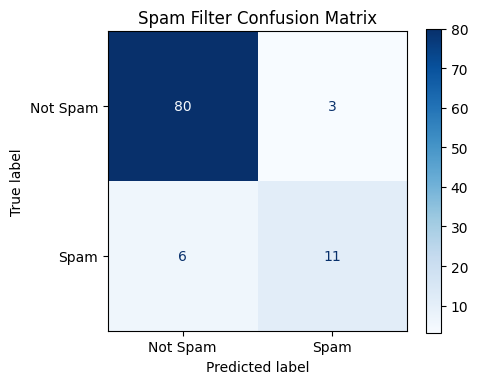

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    spam, flagged,
    display_labels=["Not Spam", "Spam"],
    cmap="Blues", ax=ax
)
ax.set_title("Spam Filter Confusion Matrix")
plt.tight_layout()

Now that we have our confusion matrix we can calculate a number of other metrics, for this practical we will focus on precision and recall. 

#### Part 1

Given three variables: a true positive count *TP*, a false positive count *FP*, and a false negative count *FN*, compute *precision* and *recall*

In [31]:
CM = confusion_matrix(spam, flagged) # this assumes this function has been 
TP = CM[1, 1] # this is pulling a value from the numpy array CM
FP = CM[0, 1] # this is pulling a value from the numpy array CM
FN = CM[1, 0] # this is pulling a value from the numpy array CM

<details>
<summary>🔢 NumPy recap with 2D array indexing using <code>M[row, col]</code></summary>

- **`confusion_matrix(y_true, y_pred)`** returns a 2D NumPy array, which is a matrix.
- Access individual cells with **`M[row, col]`**. With zero-based indexing, `M[1, 1]` means row 1 and column 1.
- In a binary confusion matrix, `M[0,0]` is TN, `M[0,1]` is FP, `M[1,0]` is FN, and `M[1,1]` is TP.
</details>

In [32]:
precision = TP / (TP + FP)  # of all flagged spam, how many were actually spam?
print(round(precision, 3))

0.786


In [33]:
recall = TP / (TP + FN)  # of all actual spam, how many did we catch?
print(round(recall, 3))

0.647


#### Part 2: Convert to Functions

Use the code you wrote in Part 2 (along with the code to pull values from a numpy array) to write functions to compute *precision* and *recall* based on a confusion matrix: 

In [34]:
def precision(M):
    """A function which takes a 2x2 confusion matrix and returns the precision"""
    TP = M[1, 1]
    FP = M[0, 1]
    return TP / (TP + FP)

In [35]:
print(round(precision(CM),3))

0.786


In [36]:
def recall(M):
    """A function which takes a 2x2 confusion matrix and returns the recall"""
    TP = M[1, 1]
    FN = M[1, 0]
    return TP / (TP + FN)

In [37]:
print(round(recall(CM), 3))

0.647


#### Part 3: Using Scikit-Learn

The library scikit-learn contains functions to calculate precision and recall. Import them from `sklearn.metrics` and test them, they should produce the same values as your solutions to Part 2.

In [38]:
# see above: from sklearn.metrics import precision_score, recall_score

print('Precision:', round(precision_score(spam, flagged), 3))
print('Recall:   ', round(recall_score(spam, flagged), 3))

Precision: 0.786
Recall:    0.647


<details>
<summary>📦 sklearn recap with <code>precision_score</code> and <code>recall_score</code></summary>

- **`precision_score(y_true, y_pred)`** asks, of all samples predicted positive, what fraction were truly positive?
- **`recall_score(y_true, y_pred)`** asks, of all truly positive samples, what fraction did the model catch?
- Both default to the positive class being `1`. For multiclass settings, set the `average` parameter, for example `'macro'` or `'weighted'`.
</details>

#### 🔍 Stop and interpret

Translate the numbers back to the spam scenario:

- **High precision** → When the filter says "spam," it's almost always right. Few real emails end up in the spam folder.
- **High recall** → The filter catches most actual spam. Few spam emails sneak into the inbox.

Look at the values you just computed. Is this spam filter better at *avoiding false alarms* (precision) or at *catching all the spam* (recall)? Which would you prioritize if this were your email?

> For more on how adjusting the decision threshold shifts the precision/recall balance, see **Section 5.3.2** in Müller and Guido, *Introduction to Machine Learning with Python*, starting from the subsection on changing the decision threshold.

### Exercise 4: F-score.

Precision and recall pull in opposite directions: push one up and the other tends to drop. In practice, you often need **a single number** to compare models or report to a stakeholder. The F₁-score is the harmonic mean of precision and recall. It stays low unless *both* are reasonably high.

$F_{1} = 2*\frac{Precision*Recall}{Precision+Recall}$

#### Part 1: Compute an F1 Score from Example Scores

In [39]:
example_precision = 0.4
example_recall = 0.6

F1 = 2 * (example_precision * example_recall) / (example_precision + example_recall)
print(F1)

0.48


#### Part 2: Convert to a Function

Using your solution from Part 1, write a function to compute the F1 score

In [40]:
def f_score(precision, recall):
    """A function which takes the precision and recall of some model, and returns the f1-score"""
    return 2 * (precision * recall) / (precision + recall)

In [41]:
print(f_score(0.4, 0.6))

0.48


#### Part 3: Writing the F-beta-score Function

F₁ treats precision and recall as equally important. F-beta is a generalisation that lets you shift that balance: a **β < 1** penalises low precision more (false alarms are costly), while a **β > 1** penalises low recall more (missing positives is costly). When β = 1 the formula reduces exactly to F₁.

Adapting your solution from Part 2, complete the *f_beta_score* function in the next cell.

$F_{\beta} = (1+\beta^{2})*\frac{Precision*Recall}{\beta^{2}*Precision+Recall}$

**Note**: The `beta=1` parameter to the function specifies a default parameter that the function will use if the `beta` parameter is not defined.

In [42]:
def f_beta_score(precision, recall, beta=1):
    """A function which takes the precision and recall of some model, and a value for beta,
    and returns the f_beta-score"""
    return (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)

<details>
<summary>🐍 Python recap with default parameter values</summary>

- **`def f(x, beta=1)`** makes `beta` optional. Callers can write `f(0.5, 0.6)` or `f(0.5, 0.6, beta=2)`.
- The default value is used only when the caller does not supply that argument.
</details>

In [43]:
print(f_beta_score(0.4, 0.6, 1))
print(round(f_beta_score(0.4, 0.6, 0.5), 3))
print(round(f_beta_score(0.4, 0.6, 2), 3))

0.48
0.429
0.545


#### Additional coding exercise 1

Now that you have defined the f_beta_score function, you can redefine the F1_score function using only a call to the `f_beta_score` function. Rewrite the `f_score` function in this way.

In [44]:
def f_score(precision, recall):
    """A function which takes the precision and recall of some model, and returns the f1-score"""
    return f_beta_score(precision, recall, beta=1)  # F1 is just F-beta with beta=1

In [45]:
print(f_score(0.4, 0.6))

0.48


#### Additional coding exercise 2

Using developed codes in Exercise 3, write a `f_score` function which takes *y_true* and *y_pred* as inputs and returns f-score.

In [ ]:
def f_score(y_true, y_pred):
    """A function which takes two lists (y_true and y_pred), and returns the f1-score.

    precision = TP / (TP + FP)  -- of all flagged positives, how many were truly positive?
    recall    = TP / (TP + FN)  -- of all actual positives, how many did we catch?
    f1        = 2 * (precision * recall) / (precision + recall)
    """
    CM = confusion_matrix(y_true, y_pred)
    p = CM[1, 1] / (CM[1, 1] + CM[0, 1])  # precision from confusion matrix
    r = CM[1, 1] / (CM[1, 1] + CM[1, 0])  # recall from confusion matrix
    return 2 * (p * r) / (p + r)

#### Part 4: Using Scikit-Learn

The library scikit-learn contains a function to calculate f1 score. Import them from `sklearn.metrics` and test it, it should produce the same values as your solutions to Part 2.

In [47]:
# see above: from sklearn.metrics import f1_score

score = f1_score(spam, flagged)
print(round(score, 3))

0.71


<details>
<summary>📦 sklearn recap with <code>f1_score</code></summary>

- **`f1_score(y_true, y_pred)`** returns the F₁ score, which is the harmonic mean of precision and recall.
- For the F-beta variant, use **`fbeta_score(y_true, y_pred, beta=2)`** from the same module.
- For multiclass problems, set `average='macro'`, `'micro'`, or `'weighted'`.
</details>

#### 📊 All metrics at a glance

Run the cell below to see accuracy, precision, recall, and F1 side-by-side for our spam filter. Notice how different the story looks compared to accuracy alone.

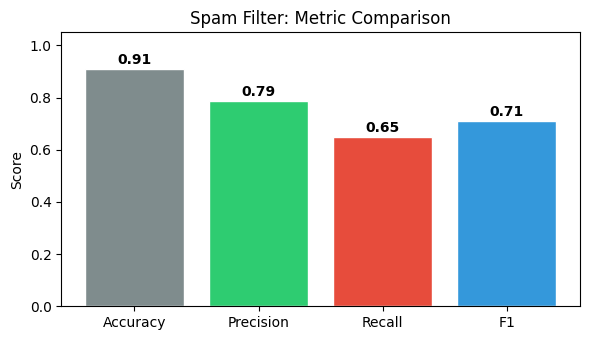

In [48]:
metric_names  = ["Accuracy", "Precision", "Recall", "F1"]
metric_values = [
    accuracy_score(spam, flagged),
    precision_score(spam, flagged),
    recall_score(spam, flagged),
    f1_score(spam, flagged),
]

colors = ["#7f8c8d", "#2ecc71", "#e74c3c", "#3498db"]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(metric_names, metric_values, color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spam Filter: Metric Comparison")
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontweight="bold")
plt.tight_layout()


<details>

<summary> 🔍 Reading the chart </summary>

**Accuracy (0.91)** looks impressive, but the lazy "always not-spam" baseline already scores 83%. Only 8 percentage points separate our filter from doing nothing.

**Precision (0.79)** means roughly 1 in 5 emails flagged as spam is actually legitimate (false positive).

**Recall (0.65)** means about 1 in 3 real spam emails slips through undetected (false negative).

**F1 (0.71)** pulls precision and recall into a single number. Because recall is low, F1 sits much below accuracy and gives a more honest picture.

The gap between the accuracy bar and the other three is the class imbalance effect. Getting the easy majority class right inflates accuracy while the hard minority class (actual spam) remains poorly handled.

</details>

#### Part 5: Understanding the Impact of Beta. *Turning the trade-off knob*

The F₁-score weights precision and recall equally, but sometimes one matters more. The $\beta$ parameter lets you tune that:

- **β < 1** → weights **precision** more (you *really* don't want false alarms e.g. "nuclear launch detected")
- **β = 1** → equal weight (the standard F₁)
- **β > 1** → weights **recall** more (you *really* don't want to miss positives, e.g. "telling a patient they're fine when they have cancer")

Once you have a working *f_beta_score* function you can run the cell below. Then **try these experiments:**

1. Set `precision = 0.9, recall = 0.3` (a cautious model that rarely cries wolf). How does the curve change?
2. Set `precision = 0.3, recall = 0.9` (an aggressive model that catches almost everything). What happens now?
3. For a medical cancer screening test, would you want β < 1 or β > 1? Why?

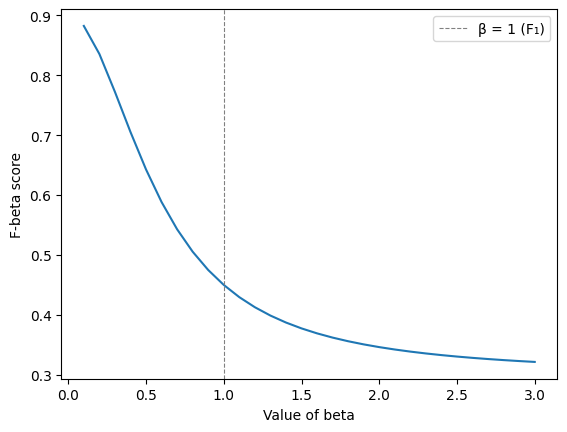

In [49]:
example_precision = 0.9
example_recall = 0.3
beta = [x * 0.1 for x in range(1, 31)]  # 0.1 to 3.0

plt.plot(beta, [f_beta_score(example_precision, example_recall, beta=b) for b in beta])
plt.axvline(x=1.0, color='grey', linestyle='--', linewidth=0.8, label='\u03b2 = 1 (F\u2081)')
plt.xlabel('Value of beta')
plt.ylabel('F-beta score')
plt.legend()


<details>

<summary> 🔍 Reading the F-beta curve </summary>

**This curve is bad.** Precision is 0.9 but recall is only 0.3, meaning the model catches just 3 in 10 actual spam emails. The steep downward slope shows that the F-beta score drops sharply as β increases, because a higher β punishes the low recall more heavily. A model that misses 70 % of real spam is not useful for most purposes, regardless of how precise it is on the cases it does flag.

A **good, balanced model** (precision ≈ recall) produces a curve that is **high and flat**. The score stays near the top of the y-axis no matter what β you choose, because neither precision nor recall is dragging it down.

A **lopsided model** produces a **steep slope**. The current plot (precision = 0.9, recall = 0.3) falls sharply from left to right. That tells you the model's perceived quality depends heavily on your choice of β. Stakeholders who care about different mistakes will disagree about whether this model is any good.

| Curve shape | What it means |
|---|---|
| High and flat | Strong model with balanced precision and recall |
| Low and flat | Weak model, but at least consistently weak |
| Steep downward slope | Precision >> recall (cautious model, fragile evaluation) |
| Steep upward slope | Recall >> precision (aggressive model, fragile evaluation) |

The steeper the slope, the more sensitive your evaluation is to the choice of β, and the more important it is to decide *upfront* which mistakes matter in your application.

</details>


---

## Wrap-up: Choosing the right metric

You now have a toolkit of evaluation metrics. The hardest part is **choosing the right one**, and that depends on the *real-world cost* of each kind of mistake.

| Scenario | Worse mistake | Metric to prioritize |
|----------|--------------|---------------------|
| Spam filter for personal email | Flagging a real email as spam (FP) | **Precision** |
| Cancer screening test | Missing a real cancer case (FN) | **Recall** |
| Self-driving car pedestrian detection | Missing a pedestrian (FN) | **Recall** (with very high β) |
| Recommending expensive financial trades | Recommending a bad trade (FP) | **Precision** |
| General-purpose comparison | Need one balanced number | **F₁-score** |

### What's next?

This notebook focused on computing metrics *after* predictions are made. But many classifiers don't just predict a label. They output a **score or probability**, and you choose a threshold to turn that into a label. Moving the threshold trades precision for recall and vice versa.

That's where **precision-recall curves**, **ROC curves**, and **AUC** come in. They evaluate a model across *all possible thresholds* at once. You'll find that story in the book if you're interested:

**Suggested reading**

<details>
<summary>Müller and Guido, <em>Introduction to Machine Learning with Python</em>, Section 5.3.2 (continued): Thresholds, Precision-Recall Curves, ROC Curves, and AUC</summary>

Most classifiers produce scores rather than hard labels. The default threshold (often 0.5) is just a starting point, and you can adjust it to match your application's cost structure. Precision-recall curves and ROC curves visualize this trade-off across all thresholds, and AUC summarizes ranking quality in a single number.

Continue in the book with the **thresholds, precision-recall curves, ROC, and AUC** sections of **Section 5.3.2**.
</details>